In [211]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import statistics

In [214]:
reac5_iter18 = '/Users/aya/github/WWDR/BSM1-BSM2_MATLAB/BSM2_R2019b/BSM2_OutputDB/Morning_4hr/iter18/settler_data_DR_iteration_18.csv'
reac5_nominal18 = '/Users/aya/github/WWDR/BSM1-BSM2_MATLAB/BSM2_R2019b/BSM2_OutputDB/Morning_4hr/iter18/settler_data_nominal_iteration_18.csv'

# Step 1: Read CSVs
nominal = pd.read_csv(reac5_nominal18)
iteration = pd.read_csv(reac5_iter18)

# Step 2: Apply column labels
column_names = [
    "S_I", "S_S", "X_I", "X_S", "X_BH", "X_BA", "X_P",
    "S_O", "S_NO", "S_NH", "S_ND", "X_ND", "S_ALK", "TSS", "Q"
]
nominal.columns = column_names
iteration.columns = column_names

# Step 3: Define EQI constants
BSS = 2
BCOD = 1
BNKj = 30
BNO = 10
BBOD5 = 2
i_XB = 0.08
i_XP = 0.06

# Helper to compute EQI
def compute_eqi(df):
    SSe = df["TSS"]
    CODe = df["S_I"] + df["S_S"] + df["X_I"] + df["X_S"] + df["X_BH"] + df["X_BA"] + df["X_P"]
    SNKje = df["S_NH"] + df["S_ND"] + df["X_ND"] + i_XB * (df["X_BH"] + df["X_BA"]) + i_XP * (df["X_I"] + df["X_P"])
    SNOe = df["S_NO"]
    BOD5e = df["S_S"] + df["X_S"]

    EQIvecinst = (BSS * SSe + BCOD * CODe + BNKj * SNKje + BNO * SNOe + BBOD5 * BOD5e) * df["Q"]/1000
    return EQIvecinst

# Step 4: Add EQI series and moving average
for df in [nominal, iteration]:
    df["EQIvecinst"] = compute_eqi(df)
    df["mR"] = df["EQIvecinst"].rolling(window=96, min_periods=1).mean()
    df["tagS"] = 0
    df["tagF"] = 0

def compute_tags_relative(iteration_df, nominal_df):
    # Compute mean and std of nominal moving average from stable region
    iteration_df["series_diff"] = ((iteration_df["EQIvecinst"] - nominal_df["EQIvecinst"]) / (10**8)).clip(lower=0)
    nominal_mR_mean = statistics.mean(iteration_df["series_diff"])
    nominal_mR_std = statistics.pstdev(iteration_df["series_diff"])

    for i in range(len(iteration_df)):
        val = iteration_df.at[i, "series_diff"]
        if val > nominal_mR_mean + 2.5 * nominal_mR_std:
            iteration_df.at[i, "tagS"] = 4
        elif val > nominal_mR_mean + 2.0 * nominal_mR_std:
            iteration_df.at[i, "tagS"] = 3
        elif val > nominal_mR_mean + 1.5 * nominal_mR_std:
            iteration_df.at[i, "tagS"] = 2
        elif val > nominal_mR_mean + nominal_mR_std:
            iteration_df.at[i, "tagS"] = 1
        else:
            iteration_df.at[i, "tagS"] = 0

# Step 6: Compute TagF
def compute_tagF(df):
    for i in range(len(df)):
        s = df["tagS"]
        if i < 4:
            continue
        if s[i] == 4:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1 and s[i-4] >= 1:
                df.at[i, "tagF"] = 4
            elif s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 4
            elif s[i-1] >= 1 and s[i-2] >= 1:
                df.at[i, "tagF"] = 3
            elif s[i-1] >= 1:
                df.at[i, "tagF"] = 3
            else:
                df.at[i, "tagF"] = 2
        if s[i] == 3:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1 and s[i-4] >= 1:
                df.at[i, "tagF"] = 4
            elif s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 4
            elif s[i-1] >= 1 and s[i-2] >= 1:
                df.at[i, "tagF"] = 3
            else:
                df.at[i, "tagF"] = 2
        elif s[i] == 2:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1 and s[i-4] >= 1:
                df.at[i, "tagF"] = 4
            elif s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 3
            elif s[i-1] >= 1 and s[i-2] >= 1:
                df.at[i, "tagF"] = 2
            else:
                df.at[i, "tagF"] = 1
        elif s[i] == 1:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1 and s[i-4] >= 1:
                df.at[i, "tagF"] = 3
            elif s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 2
            elif s[i-1] >= 1 and s[i-2] >= 1:
                df.at[i, "tagF"] = 1
            else:
                df.at[i, "tagF"] = 1
        elif s[i] == 0:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1 and s[i-4] >= 1:
                df.at[i, "tagF"] = 2
            elif s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 1
            elif s[i-1] >= 1 and s[i-2] >= 1:
                df.at[i, "tagF"] = 1
            else:
                df.at[i, "tagF"] = 0
        else:
            df.at[i, "tagF"] = 0

# Step 7: Compute TagR
# Define the 5x5 Risk Matrix (SEVERITY as rows, FREQUENCY as columns)
# Rows: Severity 0 → 4
# Cols: Frequency 0 → 4
risk_matrix = np.array([
    [0, 0, 0, 1, 2],  # Severity = 0
    [1, 1, 1, 2, 3],  # Severity = 1
    [1, 1, 2, 3, 4],  # Severity = 2
    [2, 2, 3, 4, 4],  # Severity = 3
    [2, 3, 3, 4, 4],  # Severity = 4
])

def get_tagR(severity, frequency):
    # Clamp values to valid range [0, 4] to prevent IndexError
    s = int(np.clip(severity, 0, 4))
    f = int(np.clip(frequency, 0, 4))
    return risk_matrix[s, f]

def assign_tagR(df):
    iteration["tagR"] = iteration.apply(lambda row: get_tagR(row["tagS"], row["tagF"]), axis=1)

compute_tags_relative(iteration, nominal)
compute_tagF(iteration)
assign_tagR(iteration)


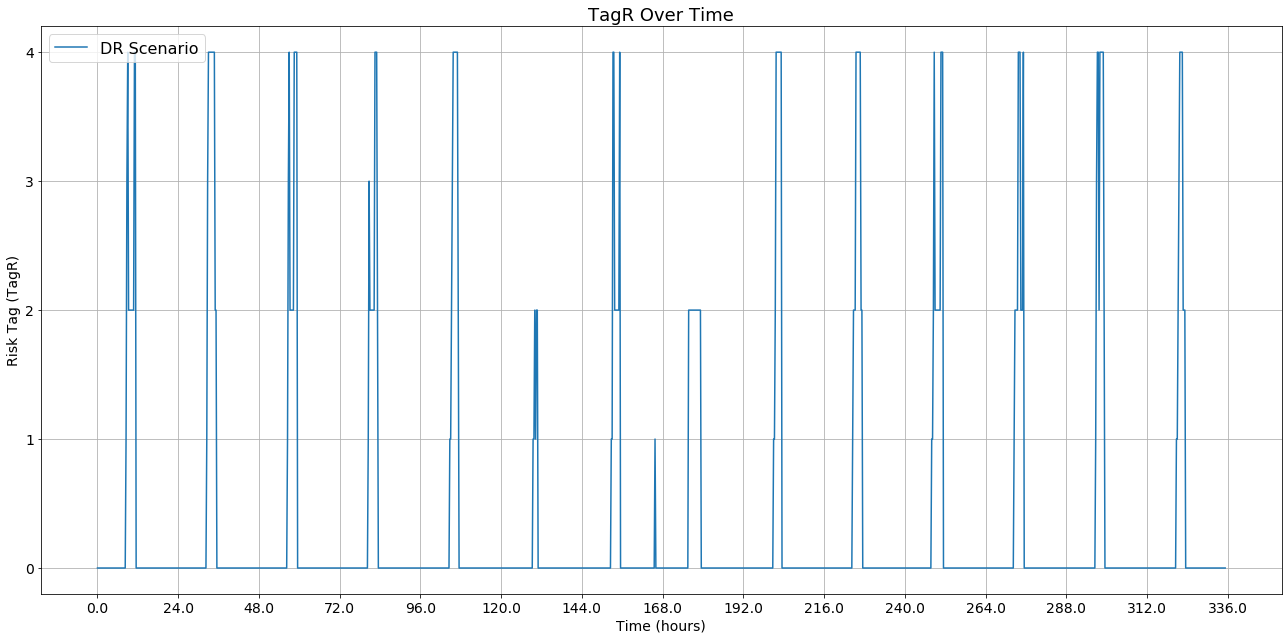

In [215]:
# Step 8: Plotting script
plt.figure(figsize=(18, 9))

#plt.plot(nominal["tagR"], label="Nominal")
plt.plot(iteration["tagR"], label="DR Scenario", linewidth=1.5)

# Set up time axis in hours
total_steps = 1344
time_step_hr = 0.25
xtick_interval = 96  # every 12 hours → 12 / 0.25 = 48 steps
ytick_interval = 1

plt.xticks(
    ticks=range(0, total_steps + 1, xtick_interval),
    labels=[f"{x * time_step_hr:.1f}" for x in range(0, total_steps + 1, xtick_interval)],
    fontsize=14
)
plt.yticks(
    ticks=range(0, 5, ytick_interval),
    #labels=[f"{x * time_step_hr:.1f}" for x in range(0, 3, ytick_interval)],
    fontsize=14
)

# Labels and title with larger font
plt.xlabel("Time (hours)", fontsize=14)
plt.ylabel("Risk Tag (TagR)", fontsize=14)
plt.title("TagR Over Time", fontsize=18)

# Larger legend font and enable grid
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

In [218]:
series_diff = ((iteration["EQIvecinst"] - nominal["EQIvecinst"]) / (10**8)).clip(lower=0)

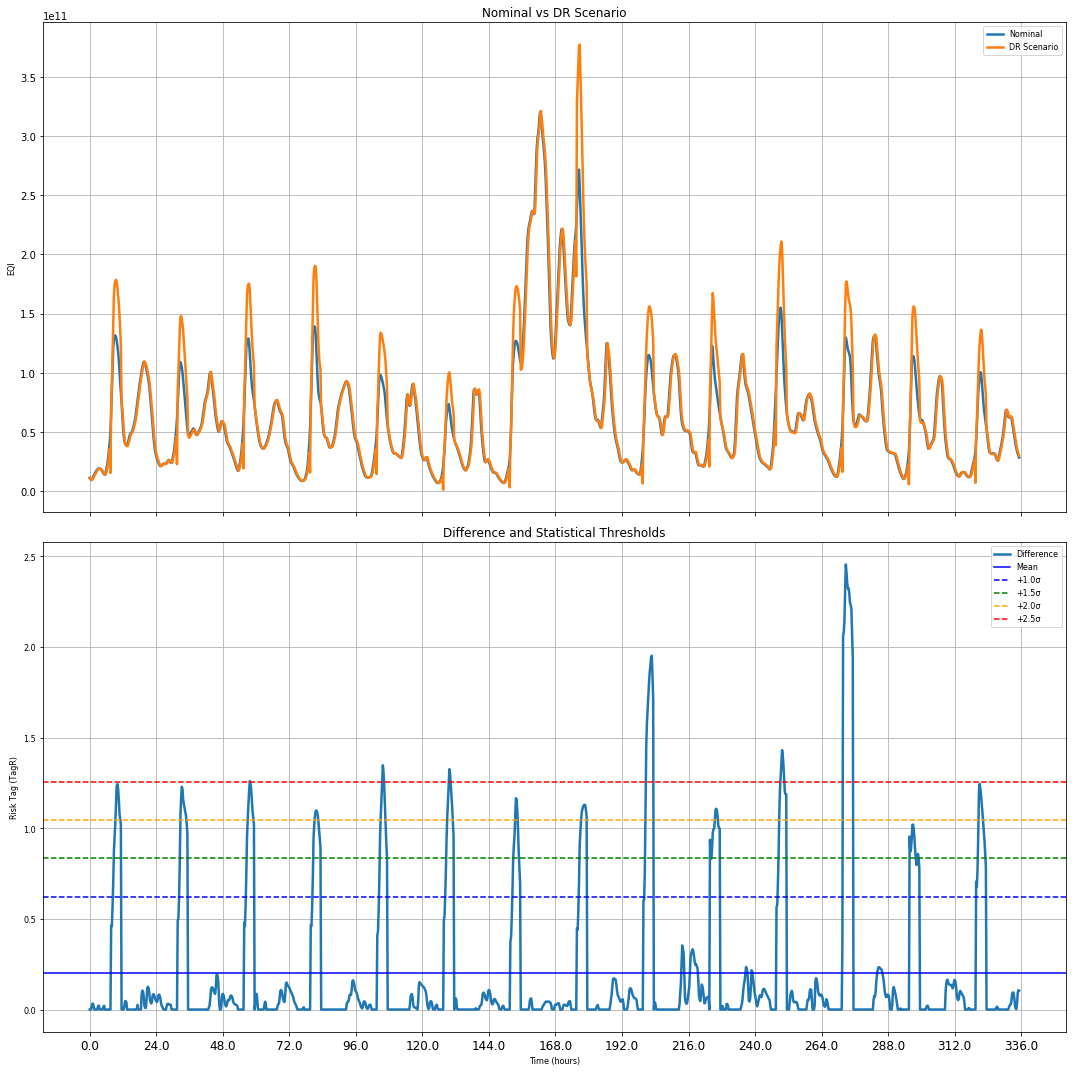

In [216]:
# Step 8: Modified Plotting Script
fig, axs = plt.subplots(2, figsize=(15, 15), sharex=True)

# First subplot: Nominal and Iteration series
axs[0].plot(nominal["EQIvecinst"], label="Nominal", linewidth=2.5)
axs[0].plot(iteration["EQIvecinst"], label="DR Scenario", linewidth=2.5)
axs[0].legend(fontsize=8)
axs[0].set_ylabel("EQI", fontsize=8)
axs[0].set_title("Nominal vs DR Scenario", fontsize=12)
axs[0].grid(True)

# Second subplot: Difference and statistical lines
axs[1].plot(series_diff, label="Difference", linewidth=2.5)
axs[1].axhline(statistics.mean(series_diff), color='blue', label='Mean')
axs[1].axhline(statistics.mean(series_diff) + 1.0 * statistics.pstdev(series_diff), color='blue', linestyle='dashed', label='+1.0σ')
axs[1].axhline(statistics.mean(series_diff) + 1.5 * statistics.pstdev(series_diff), color='green', linestyle='dashed', label='+1.5σ')
axs[1].axhline(statistics.mean(series_diff) + 2.0 * statistics.pstdev(series_diff), color='orange', linestyle='dashed', label='+2.0σ')
axs[1].axhline(statistics.mean(series_diff) + 2.5 * statistics.pstdev(series_diff), color='red', linestyle='dashed', label='+2.5σ')
axs[1].legend(fontsize=8)
axs[1].set_ylabel("Risk Tag (TagR)", fontsize=8)
axs[1].set_title("Difference and Statistical Thresholds", fontsize=12)
axs[1].grid(True)

# Set up time axis in hours
total_steps = 1344
time_step_hr = 0.25
xtick_interval = 96  # every 12 hours → 12 / 0.25 = 48 steps

plt.xticks(
    ticks=range(0, total_steps + 1, xtick_interval),
    labels=[f"{x * time_step_hr:.1f}" for x in range(0, total_steps + 1, xtick_interval)],
    fontsize=12
)
plt.xlabel("Time (hours)", fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()


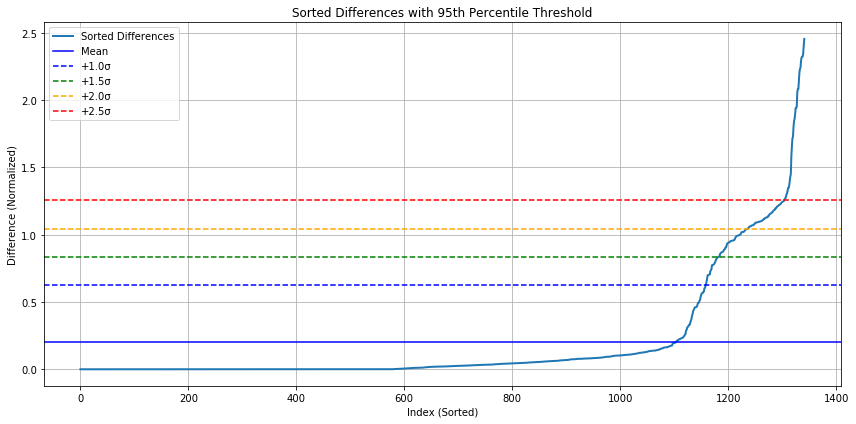

In [217]:
# Sort the series by value (magnitude)
sorted_diff = series_diff.sort_values().reset_index(drop=True)

# Calculate the 95th percentile
percentile_95 = sorted_diff.quantile(0.95)

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(sorted_diff, label="Sorted Differences", linewidth=2.0)
#plt.axhline(percentile_95, color='black', linestyle='dashed', label="95th Percentile")
plt.axhline(statistics.mean(series_diff), color='blue', label='Mean')
plt.axhline(statistics.mean(series_diff) + 1.0 * statistics.pstdev(series_diff), color='blue', linestyle='dashed', label='+1.0σ')
plt.axhline(statistics.mean(series_diff) + 1.5 * statistics.pstdev(series_diff), color='green', linestyle='dashed', label='+1.5σ')
plt.axhline(statistics.mean(series_diff) + 2.0 * statistics.pstdev(series_diff), color='orange', linestyle='dashed', label='+2.0σ')
plt.axhline(statistics.mean(series_diff) + 2.5 * statistics.pstdev(series_diff), color='red', linestyle='dashed', label='+2.5σ')

# Labeling
plt.xlabel("Index (Sorted)", fontsize=10)
plt.ylabel("Difference (Normalized)", fontsize=10)
plt.title("Sorted Differences with 95th Percentile Threshold", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()


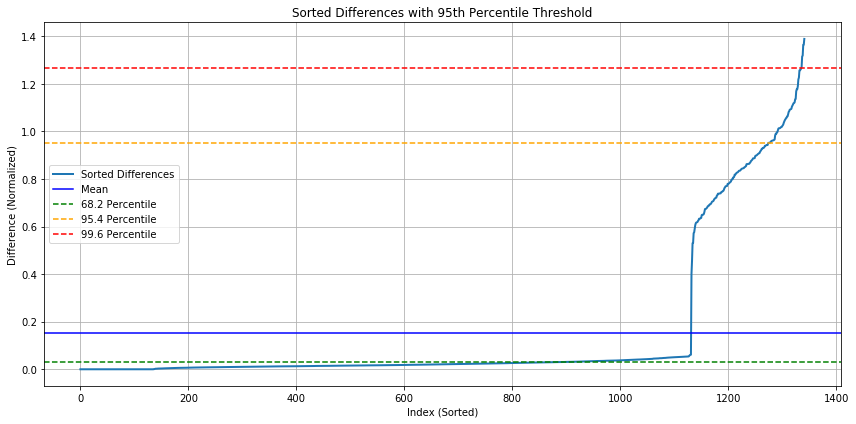

In [58]:
# Sort the series by value (magnitude)
sorted_diff = series_diff.sort_values().reset_index(drop=True)

# Calculate the percentiles
percentile_682 = sorted_diff.quantile(0.682)
percentile_95 = sorted_diff.quantile(0.95)
percentile_996 = sorted_diff.quantile(0.996)

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(sorted_diff, label="Sorted Differences", linewidth=2.0)
plt.axhline(statistics.mean(series_diff), color='blue', label='Mean')
plt.axhline(percentile_682, color='green', linestyle='dashed', label="68.2 Percentile")
plt.axhline(percentile_95, color='orange', linestyle='dashed', label="95.4 Percentile")
plt.axhline(percentile_996, color='red', linestyle='dashed', label="99.6 Percentile")

# Labeling
plt.xlabel("Index (Sorted)", fontsize=10)
plt.ylabel("Difference (Normalized)", fontsize=10)
plt.title("Sorted Differences with Percentile Thresholds", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()
